# UNAD - Analisis de Datos

## John Alejandro Ceballos Castaño

### Predicción de Heart Disease Cleveland UCI con Regresión Logística

### Pasos de la Actividad
1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.
2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario
3. Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características
4. Dividir el dataset en Train y Test para evaluar correctamente el modelo
5. Entrenar el modelo configurando los diferentes hiperparámetros
6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc
7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.
8. Interpretar, analizar y documentar los resultados obtenidos

### 1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.

In [1]:
#Cargar las librerias necesarias

import pandas as pd # Manejo y análisis de estructuras de datos
import numpy as np # Cálculo numérico y el análisis de datos
import seaborn as sns # Creación gráficos estadísticos
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones

# librerías de para implementar modelos de ciencia de datos
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# lectura de datos en Python y lo cargamos en la variable Datos

Datos = pd.read_csv('C:/Users/Alejandro/Documents/MEGA/UNAD/Periodo 6/Analisis de Datos/Tarea 3/Heart Disease Cleveland/heart_cleveland_upload.csv')

In [3]:
# Realizamos lectura de los Datos para el análisis exploratorio

Datos.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


In [4]:
# Descripción de los datos
Datos.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

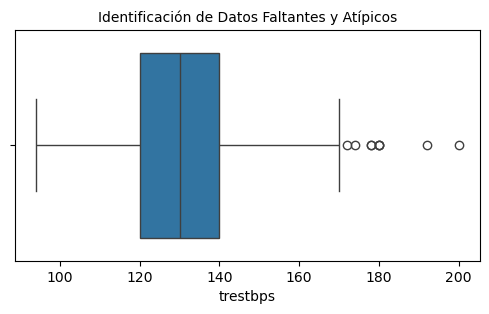

In [5]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['trestbps'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

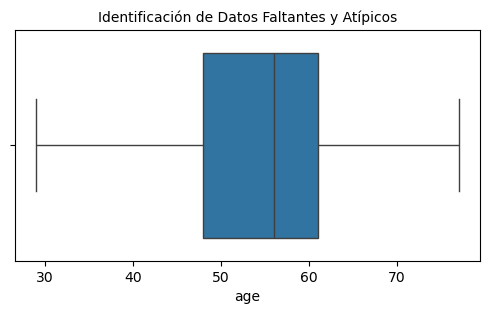

In [6]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['age'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

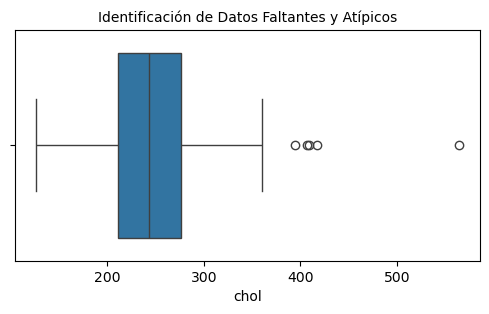

In [7]:
#Identificación de Datos Faltantes y Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['chol'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

### 2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario

In [8]:
#Revisión del tipo de datos y datos faltantes

Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [9]:
#Revisión de datos faltantes

print("Cantidad de Registros con cero en Edad: ",Datos['age'].isin([0]).sum())
print("Cantidad de Registros con cero en Presión Arterial: ",Datos['trestbps'].isin([0]).sum())
print("Cantidad de Registros con cero en Colesterol: ",Datos['chol'].isin([0]).sum())
print("Cantidad de Registros con cero en frecuencia cardíaca máxima: ",Datos['thalach'].isin([0]).sum())
print("")
print("No hay informacion faltante o campos vacios en el Dataset")


Cantidad de Registros con cero en Edad:  0
Cantidad de Registros con cero en Presión Arterial:  0
Cantidad de Registros con cero en Colesterol:  0
Cantidad de Registros con cero en frecuencia cardíaca máxima:  0

No hay informacion faltante o campos vacios en el Dataset


In [10]:
#Conteo de Datos Atípicos

nivel_minimo=50
nivel_maximo=170
Total_Atipicos=((Datos['trestbps']<nivel_minimo)|(Datos['trestbps']>nivel_maximo)).sum()
print("El total de datos atípicos para Presion Arterial es {}".format(Total_Atipicos))

El total de datos atípicos para Presion Arterial es 9


In [11]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['trestbps']<nivel_maximo)&(Datos['trestbps']>nivel_minimo)]

In [12]:
Total_Atipicos=((Datos['trestbps']<nivel_minimo)|(Datos['trestbps']>nivel_maximo)).sum()
print("El total de datos atípicos es {}".format(Total_Atipicos))

El total de datos atípicos es 0


In [13]:
#Conteo de Datos Atípicos

nivel_minimo1=20
nivel_maximo1=380
Total_Atipicos=((Datos['chol']<nivel_minimo1)|(Datos['chol']>nivel_maximo1)).sum()
print("El total de datos atípicos para colesterol es {}".format(Total_Atipicos))

El total de datos atípicos para colesterol es 5


In [14]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['chol']<nivel_maximo1)&(Datos['chol']>nivel_minimo1)]

In [15]:
Total_Atipicos=((Datos['chol']<nivel_minimo1)|(Datos['chol']>nivel_maximo1)).sum()
print("El total de datos atípicos es {}".format(Total_Atipicos))

El total de datos atípicos es 0


Text(0.5, 1.0, 'Validacion de Datos Atípicos')

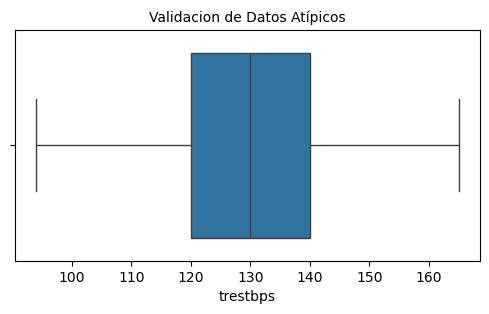

In [16]:
#Identificación de Datos Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['trestbps'])
plt.title('Validacion de Datos Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Validacion de Datos Atípicos')

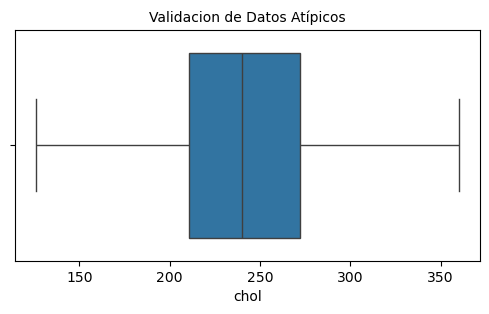

In [17]:
#Identificación de Datos Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['chol'])
plt.title('Validacion de Datos Atípicos', fontsize=10 )

In [18]:
#Revisión del tipo de datos y datos faltantes

Datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        279 non-null    int64  
 1   sex        279 non-null    int64  
 2   cp         279 non-null    int64  
 3   trestbps   279 non-null    int64  
 4   chol       279 non-null    int64  
 5   fbs        279 non-null    int64  
 6   restecg    279 non-null    int64  
 7   thalach    279 non-null    int64  
 8   exang      279 non-null    int64  
 9   oldpeak    279 non-null    float64
 10  slope      279 non-null    int64  
 11  ca         279 non-null    int64  
 12  thal       279 non-null    int64  
 13  condition  279 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.7 KB


### 3.Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características

Característica de interes:

condition: si la persona tiene enfermedad cardiaca o no (0 = sin enfermedad - 1 = enfermedad)

Predecir si una persona tiene enfermedad cardiaca

In [19]:
# Total de personas con Enfermedades Cardiacas

Datos['condition'].value_counts()

condition
0    153
1    126
Name: count, dtype: int64

### 4. Dividir el dataset en Train y Test para evaluar correctamente el modelo

In [20]:
# Porcentaje de datos para entrenamiento (train) = 75% , y para prueba (test) = 25%

# Se crean variables X y Y para almacenar la información del entrenamiento

X = Datos.drop('condition',axis=1) # Se cargan los datos de train sin los datos de la columna Diabetico 
Y = Datos['condition'] # Se cargan los datos de train con los datos de la la columna Diabetico

#La función train_test_split crea una división de un conjunto de datos en dos bloques uno de entrenamiento y otro de prueba (train and test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, stratify=Y, random_state= 0)

In [21]:
print (X_train)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
21    38    1   0       120   231    0        0      182      1      3.8   
56    45    0   1       130   234    0        2      175      0      0.6   
203   60    1   3       117   230    1        0      160      1      1.4   
150   39    0   2       138   220    0        0      152      0      0.0   
126   50    1   2       140   233    0        0      163      0      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
82    66    0   2       146   278    0        2      152      0      0.0   
19    42    1   0       148   244    0        2      178      0      0.8   
99    58    1   2       105   240    0        2      154      1      0.6   
12    59    1   0       134   204    0        0      162      0      0.8   
217   58    1   3       146   218    0        0      105      0      2.0   

     slope  ca  thal  
21       1   0     2  
56       1   0     0  
203      0   2    

In [22]:
print (X_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
197   61    1   3       148   203    0        0      161      0      0.0   
87    64    1   2       140   335    0        0      158      0      0.0   
192   61    1   3       120   260    0        0      140      1      3.6   
48    52    1   1       128   205    1        0      184      0      0.0   
122   51    0   2       130   256    0        2      149      0      0.5   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
52    48    1   1       110   229    0        0      168      0      1.0   
157   70    1   3       145   174    0        0      125      1      2.6   
106   56    1   2       130   256    1        2      142      1      0.6   
96    59    1   2       126   218    1        0      134      0      2.2   
210   59    1   3       164   176    1        2       90      0      1.0   

     slope  ca  thal  
197      0   1     2  
87       0   0     0  
192      1   1    

### 5. Entrenar el modelo configurando los diferentes hiperparámetros

In [23]:
# Construir el modelo de regresión logística 

modelo_regresion = LogisticRegression(solver = "liblinear") # liblinear es una libreria para resolver problemas lineales de clasificación y regresión
modelo_regresion.fit (X_train , Y_train)   

# Crea el modelo de prediccion
Prediccion = modelo_regresion.predict(X_test) # la función predict predice los valores a partir del conjunto de datos de validación

In [24]:
X_test.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
197,61,1,3,148,203,0,0,161,0,0.0,0,1,2
87,64,1,2,140,335,0,0,158,0,0.0,0,0,0
192,61,1,3,120,260,0,0,140,1,3.6,1,1,2
48,52,1,1,128,205,1,0,184,0,0.0,0,0,0
122,51,0,2,130,256,0,2,149,0,0.5,0,0,0
16,52,1,0,152,298,1,0,178,0,1.2,1,0,2
49,50,0,1,120,244,0,0,162,0,1.1,0,0,0
155,77,1,3,125,304,0,2,162,1,0.0,0,3,0
65,41,0,1,105,198,0,0,168,0,0.0,0,1,0
104,57,1,2,150,168,0,0,174,0,1.6,0,0,0


In [25]:
print (Prediccion)

[0 0 1 0 0 0 0 1 0 0 1 0 1 0 1 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 1
 1 1 0 0 1 0 0 1 0 0 1 1 0 1 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1 1 1 1]


### 6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc

In [26]:
# Desempeño del modelo de regresión

print(classification_report(Y_test,Prediccion))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87        38
           1       0.87      0.81      0.84        32

    accuracy                           0.86        70
   macro avg       0.86      0.85      0.86        70
weighted avg       0.86      0.86      0.86        70



### 7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo

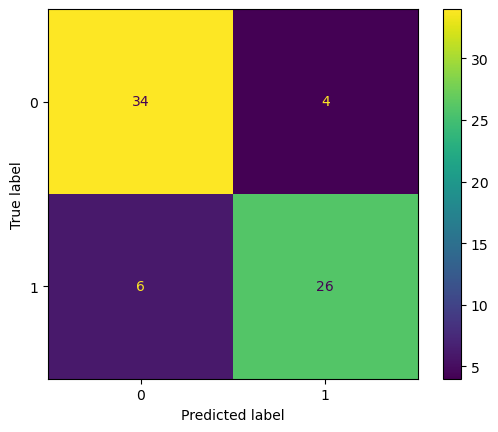

In [27]:
#Matrix de Confusión del modelo

cm=confusion_matrix(Y_test,Prediccion)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

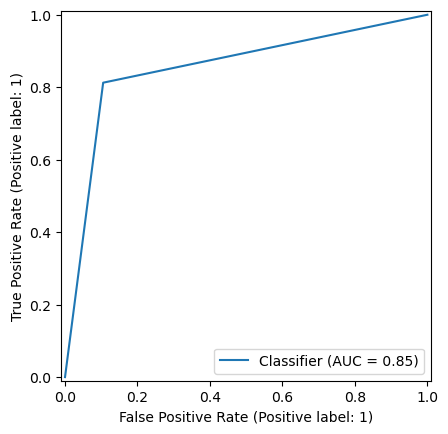

In [28]:
# Curva de precisón del modelo

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(Y_test, Prediccion)
plt.show()

### 8. Interpretar, analizar y documentar los resultados obtenidos

Del desempeño del modelo se puede describir:

Precisión: Precisión mide la proporción de predicciones positivas verdaderas entre todas las predicciones positivas realizadas por el modelo. Aquí la precisión para la clase "condition" es 0,87, lo que significa que el 87% de los predichos como enfermos por el modelo eran en realidad enfermos cardiacos.

Recall: Mide la proporción de predicciones positivas verdaderas entre todas las instancias positivas reales en el conjunto de datos. Aquí el Recall para la clase "condition" es 0,81, lo que indica que el modelo identificó correctamente al 81% de todos los enfermos cardiacos.

F1 Score: Es la media armónica de precisión y recall. Proporciona una puntuación única que equilibra la precisión y recall. Aquí la puntuación F1 para la clase "condition" es 0,84, lo que indica un equilibrio entre precisión y recall.

De la Matriz de Confusión podemos interpretar:

Verdaderos negativos: el recuento de observaciones que un clasificador predijo correctamente como falso 34

Verdaderos positivos: el recuento de observaciones que un clasificador predijo correctamente como Verdadero 26

Falsos positivos: el recuento de observaciones que un clasificador predijo incorrectamente como Verdaderas 4

Falsos negativos: el recuento de observaciones que un clasificador predijo incorrectamente como falso 6

De la curva de precisión del modelo se puede interpretar:

El AUC es 0,85 lo que significa que el 85% de las predicciones del clasificador son correctas en todos los umbrales de clasificación.